In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import time
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import gc
import tensorflow as tf

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils import resample

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# --- CONFIGURAÇÕES GLOBAIS ---
RANDOM_STATE = 42
NPZ_PATH = '/content/drive/MyDrive/2026/ic/npz_files/opportunity_v2.npz'
N_BOOTSTRAP_ITERATIONS = 1000

# Garantir Reprodutibilidade em Deep Learning
def set_seeds(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(RANDOM_STATE)


In [ ]:
def load_data_and_split(path):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        # Forçar float32 resolve o problema de compatibilidade TensorFlow x NumPy 2.0
        X_train = data['X_train'].astype(np.float32)
        y_train = data['y_train']
        X_val   = data['X_val'].astype(np.float32)
        y_val   = data['y_val']
        X_test  = data['X_test'].astype(np.float32)
        y_test  = data['y_test']
    except FileNotFoundError:
        print(" Erro: Arquivo não encontrado.")
        return None

    # Codificação de classes
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)
    y_test_enc = le.transform(y_test)
    num_classes = len(le.classes_)

    print(f"   Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

    return (X_train, y_train_enc), (X_val, y_val_enc), (X_test, y_test_enc), num_classes

def prep_dl_data(X_train, X_val, X_test, mode='raw'):
    if mode == 'raw':
        # Dados já foram escalonados no pré-processamento (.npz)
        return X_train, X_val, X_test

    elif mode == 'features':
        # MLP: Extração Manual
        def extract(X):
            return np.hstack([np.mean(X, axis=1), np.std(X, axis=1), np.max(X, axis=1), np.min(X, axis=1)])

        X_tr_feat = extract(X_train)
        X_val_feat = extract(X_val)
        X_te_feat = extract(X_test)

        # Como são novas features extraídas, aplicamos o scaler nelas
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_feat)
        X_val_sc = scaler.transform(X_val_feat)
        X_te_sc = scaler.transform(X_te_feat)

        return X_tr_sc, X_val_sc, X_te_sc


In [ ]:
def sparse_categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())

        # One-hot encode the true labels
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(tf.squeeze(y_true, axis=-1) if tf.rank(y_true) > 1 else y_true, num_classes)

        # Calculate cross entropy
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)

        # Calculate focal loss
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        focal = weight * cross_entropy

        return tf.reduce_sum(focal, axis=-1)
    return loss

def build_cnn(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    model.add(Conv1D(filters=params.get('filters_1', 64),
                     kernel_size=params.get('kernel_1', 5), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(params.get('dropout', 0.2)))

    model.add(Conv1D(filters=params.get('filters_2', 128),
                     kernel_size=params.get('kernel_2', 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(params.get('dropout', 0.3)))

    model.add(Dense(params.get('dense_units', 64), activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss=sparse_categorical_focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])
    return model

def build_mlp(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    model.add(Dense(params.get('units_1', 256), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.4)))

    model.add(Dense(params.get('units_2', 128), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.3)))

    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss=sparse_categorical_focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])
    return model


In [ ]:
def run_optuna_dl(X_tr, y_tr, X_val, y_val, mode, num_classes):
    def objective(trial):
        tf.keras.backend.clear_session()
        params = {
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        }
        if mode == 'raw':
            params.update({
                'filters_1': trial.suggest_categorical('filters_1', [32, 64]),
                'filters_2': trial.suggest_categorical('filters_2', [64, 128]),
                'kernel_1': trial.suggest_categorical('kernel_1', [5, 7]),
                'kernel_2': trial.suggest_categorical('kernel_2', [3, 5]),
                'dense_units': trial.suggest_categorical('dense_units', [32, 64])
            })
            model = build_cnn(X_tr.shape[1:], num_classes, params)
        else:
            params.update({
                'units_1': trial.suggest_categorical('units_1', [128, 256, 512]),
                'units_2': trial.suggest_categorical('units_2', [64, 128])
            })
            model = build_mlp(X_tr.shape[1:], num_classes, params)

        weight_factor = trial.suggest_float('weight_factor', 1.0, 50.0)
        classes = np.unique(y_tr)
        class_weights = {int(c): float(1.0 if c == 0 else weight_factor) for c in classes}

        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=10, batch_size=64, verbose=0, class_weight=class_weights,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])

        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        return f1_score(y_val, y_pred, average='macro')

    print(f"\n [Optuna] Otimizando DL ({mode})...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)
    print(f"   Best Params: {study.best_params}")
    return study.best_params

def run_experiments_dl(X_train, y_train, X_val, y_val, X_test, y_test, params, mode, num_classes, scenario_name):
    import gc
    from sklearn.metrics import confusion_matrix
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.backend.clear_session()

    if params == 'balanced':
        from sklearn.utils.class_weight import compute_class_weight
        w_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        # Converter para dict nativo
        class_weights = {int(k): float(v) for k, v in enumerate(w_arr)}
        model_params = {}
    else:
        p = params.copy()
        w_factor = p.pop('weight_factor')
        classes = np.unique(y_train)
        class_weights = {int(c): float(1.0 if c == 0 else w_factor) for c in classes}
        model_params = p

    if mode == 'raw':
        model = build_cnn(X_train.shape[1:], num_classes, model_params)
    else:
        model = build_mlp(X_train.shape[1:], num_classes, model_params)

    print(f"\n [Treinamento] Cenário: {scenario_name}...")
    start = time.time()

    model.fit(X_train, y_train,
              epochs=50,
              batch_size=64,
              validation_data=(X_val, y_val),
              class_weight=class_weights,
              verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)])

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    duration = time.time() - start
    print(f"   Treinamento concluído em {duration:.2f}s")

    stats_f1 = []
    stats_acc = []
    for _ in range(N_BOOTSTRAP_ITERATIONS):
        y_true_res, y_pred_res = resample(y_test, y_pred, random_state=None)
        stats_f1.append(f1_score(y_true_res, y_pred_res, average='macro'))
        stats_acc.append(accuracy_score(y_true_res, y_pred_res))

    cm = confusion_matrix(y_test, y_pred, normalize='true')

    return {
        'Cenário': scenario_name,
        'F1_Mean': np.mean(stats_f1),
        'F1_CI_Lower': np.percentile(stats_f1, 2.5),
        'F1_CI_Upper': np.percentile(stats_f1, 97.5),
        'Acc_Mean': np.mean(stats_acc),
        'Acc_CI_Lower': np.percentile(stats_acc, 2.5),
        'Acc_CI_Upper': np.percentile(stats_acc, 97.5),
        'CM': cm
    }

 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/opportunity_v2.npz...
   Treino: (12411, 75, 242) | Val: (5852, 75, 242) | Teste: (5198, 75, 242)

 [Treinamento] Cenário: Raw + balanced...
   Treinamento concluído em 35.48s

 [Optuna] Otimizando DL (raw)...
   Best Params: {'lr': 0.0014967342469169866, 'dropout': 0.11384249019390597, 'filters_1': 32, 'filters_2': 64, 'kernel_1': 7, 'kernel_2': 5, 'dense_units': 32, 'weight_factor': 46.079043200691366}

 [Treinamento] Cenário: Raw + optimized...
   Treinamento concluído em 31.12s

 [Treinamento] Cenário: Features + balanced...
   Treinamento concluído em 29.63s

 [Optuna] Otimizando DL (features)...
   Best Params: {'lr': 0.0018184238004056955, 'dropout': 0.3790798046343248, 'units_1': 512, 'units_2': 64, 'weight_factor': 15.12579425781285}

 [Treinamento] Cenário: Features + optimized...
   Treinamento concluído em 20.76s


 RELATÓRIO FINAL: DEEP LEARNING (OPPORTUNITY)


,Cenário,F1_Mean,F1_CI_Lower,F1_CI_Upper,Acc_Mean,Acc_CI_Lower,Acc_CI_Upper
0,Raw + balanced,0.215722,0.192013,0.237817,0.599697,0.586764,0.613510
1,Raw + optimized,0.222814,0.199960,0.248823,0.563731,0.550207,0.577727
2,Features + balanced,0.280463,0.257105,0.304914,0.706187,0.693531,0.718358
3,Features + optimized,0.301828,0.276399,0.328263,0.740405,0.729127,0.751828


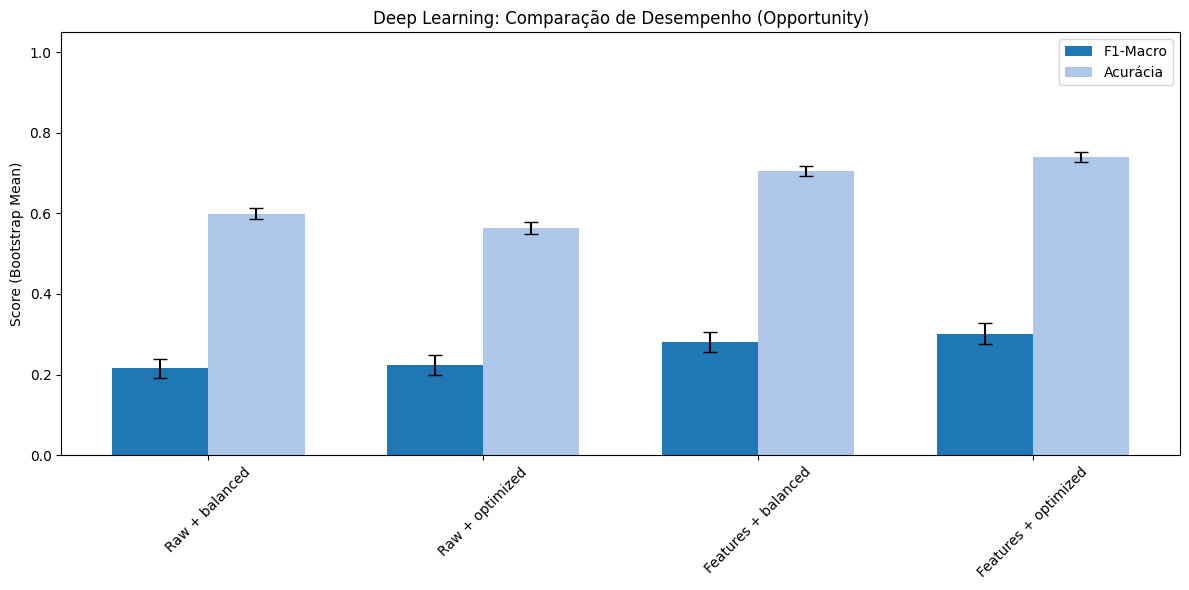

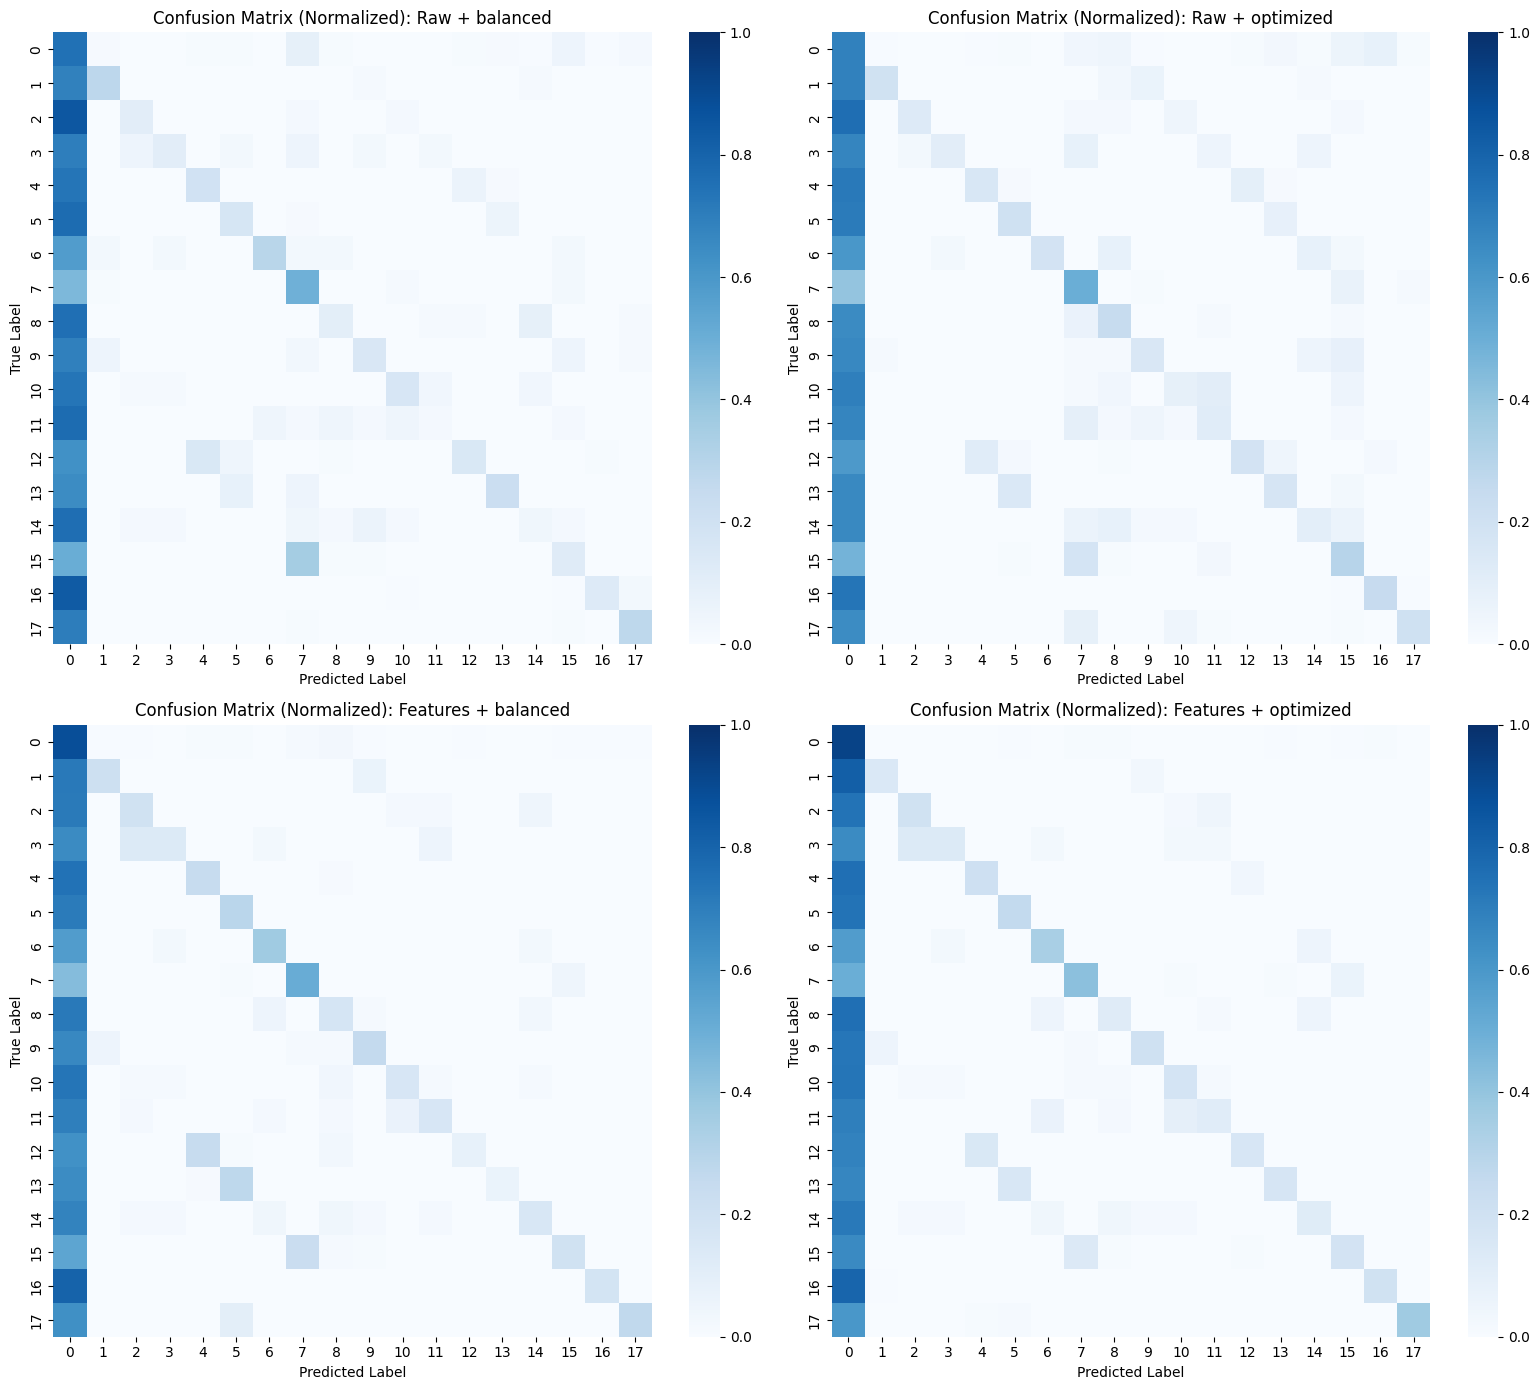

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import gc

def sparse_categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())

        # Garantir que y_true seja 1D
        y_true_flat = tf.reshape(y_true, [-1])

        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true_flat, num_classes)

        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        focal = weight * cross_entropy

        return tf.reduce_sum(focal, axis=-1)
    return loss

def build_cnn(input_shape, n_classes, params):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Input
    from tensorflow.keras.optimizers import Adam
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv1D(filters=params.get('filters_1', 64), kernel_size=params.get('kernel_1', 5), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(params.get('dropout', 0.2)))
    model.add(Conv1D(filters=params.get('filters_2', 128), kernel_size=params.get('kernel_2', 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(params.get('dropout', 0.3)))
    model.add(Dense(params.get('dense_units', 64), activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss=sparse_categorical_focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])
    return model

def build_mlp(input_shape, n_classes, params):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
    from tensorflow.keras.optimizers import Adam
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(params.get('units_1', 256), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.4)))
    model.add(Dense(params.get('units_2', 128), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.3)))
    model.add(Dense(n_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss=sparse_categorical_focal_loss(gamma=2.0, alpha=0.25), metrics=['accuracy'])
    return model

splits = load_data_and_split(NPZ_PATH)

if splits:
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te), NUM_CLASSES = splits
    final_report = []

    scenarios = [("Raw", "balanced"), ("Raw", "optimized"), ("Features", "balanced"), ("Features", "optimized")]

    for data_type, param_type in scenarios:
        mode = 'raw' if data_type == 'Raw' else 'features'

        X_tr_sc, X_val_sc, X_te_sc = prep_dl_data(X_tr, X_val, X_te, mode)

        if param_type == 'optimized':
            best_params = run_optuna_dl(X_tr_sc, y_tr, X_val_sc, y_val, mode, NUM_CLASSES)
        else:
            best_params = 'balanced'

        res = run_experiments_dl(
            X_tr_sc, y_tr, X_val_sc, y_val, X_te_sc, y_te,
            best_params, mode, NUM_CLASSES, f"{data_type} + {param_type}"
        )

        final_report.append(res)
        gc.collect()

    df_results = pd.DataFrame(final_report)

    # Display table without the Confusion Matrix array column
    df_table = df_results.drop(columns=['CM'])
    print("\n\n RELATÓRIO FINAL: DEEP LEARNING (OPPORTUNITY)")
    display(df_table)

    # Tabela comparativa (Gráfico de barras / Histograma Azul)
    x = np.arange(len(df_results))
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, df_results['F1_Mean'], width, label='F1-Macro', color='#1f77b4') # Azul Escuro
    plt.bar(x + width/2, df_results['Acc_Mean'], width, label='Acurácia', color='#aec7e8') # Azul Claro

    # Adicionando as barras de erro para o intervalo de confiança
    yerr_f1 = [
        df_results['F1_Mean'] - df_results['F1_CI_Lower'],
        df_results['F1_CI_Upper'] - df_results['F1_Mean']
    ]
    yerr_acc = [
        df_results['Acc_Mean'] - df_results['Acc_CI_Lower'],
        df_results['Acc_CI_Upper'] - df_results['Acc_Mean']
    ]

    plt.errorbar(x - width/2, df_results['F1_Mean'], yerr=yerr_f1, fmt='none', c='black', capsize=5)
    plt.errorbar(x + width/2, df_results['Acc_Mean'], yerr=yerr_acc, fmt='none', c='black', capsize=5)

    plt.title('Deep Learning: Comparação de Desempenho (Opportunity)')
    plt.ylabel('Score (Bootstrap Mean)')
    plt.ylim(0.0, 1.05)
    plt.xticks(x, df_results['Cenário'], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plote das matrizes de confusão
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    for i, row in df_results.iterrows():
        sns.heatmap(row['CM'], annot=False, cmap='Blues', ax=axes[i], cbar=True, vmin=0, vmax=1)
        axes[i].set_title(f"Confusion Matrix (Normalized): {row['Cenário']}")
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')
    plt.tight_layout()
    plt.show()

else:
    print(" Erro ao carregar dados.")